In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el dataset
df = pd.read_csv('../Data/global_tech_startups_2026.csv')

# 2. Exploración inicial con Pandas
print("--- Dimensión del Dataset ---")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}\n")

print("--- Primeras 5 Filas ---")
display(df.head())

# 3. Operaciones Vectorizadas con NumPy (Módulo 1)
# Convertimos columnas financieras a arrays de NumPy para cálculo algebraico rápido
valuations = df['Valuation_USD_Millions'].to_numpy()
revenues = df['Revenue_ARR_Millions'].to_numpy()

# Múltiplo de Valoración = Valuation / Revenue (Evitando división por cero)
multiples = np.divide(valuations, revenues, out=np.zeros_like(valuations), where=revenues != 0)

# Asignamos el resultado de vuelta al DataFrame
df['Valuation_Multiple'] = multiples

print("\n--- Estadísticas del Múltiplo de Valoración (Calculado con NumPy) ---")
print(f"Promedio: {np.mean(multiples):.2f}x")
print(f"Mediana: {np.median(multiples):.2f}x")
print(f"Máximo: {np.max(multiples):.2f}x")

--- Dimensión del Dataset ---
Filas: 25000, Columnas: 17

--- Primeras 5 Filas ---


,Company_ID,Domain,Founding_Year,Country,City,Funding_Stage,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions,Runway_Months_2024,Peak_Headcount_2023,Layoffs_2024_2025,Current_Headcount_2026,Investor_Tier,AI_Adoption_Level,Acquisition_Status
0,B730AD52,HealthTech,2014,Canada,Montreal,Seed,1.64,17.81,1.46,0.33,3.8,23,0,23,Tier 3 (Angel/Seed),High,Independent
1,65A5F690,Web3/Crypto,2014,China,Beijing,Pre-IPO,103.87,949.16,32.77,2.42,41.2,242,146,96,Tier 3 (Angel/Seed),NaN,Closed
2,F106C853,Cybersecurity,2020,USA,San Francisco,Series A,10.08,43.37,2.16,1.01,9.1,59,0,59,Tier 2 (Mid-size VC),High,Independent
3,2BD798AF,FinTech,2023,India,Delhi NCR,Series B,32.28,257.62,11.66,0.78,36.7,76,0,76,Tier 3 (Angel/Seed),Medium,Independent
4,C5CB4451,Generative AI,2020,USA,New York,Series C+,13.41,76.73,2.57,1.12,11.0,59,28,31,Tier 2 (Mid-size VC),Medium,Closed



--- Estadísticas del Múltiplo de Valoración (Calculado con NumPy) ---
Promedio: 17.44x
Mediana: 17.42x
Máximo: 30.70x


In [2]:
# 1. Verificar valores faltantes iniciales
print("--- Valores faltantes por columna ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

# 2. Imputación no paramétrica: Moda de 'AI_Adoption_Level' según el 'Domain'
mode_by_domain = df.groupby('Domain')['AI_Adoption_Level'].apply(
    lambda x: x.mode()[0] if not x.mode().empty else 'Low'
)

print("\n--- Moda de Adopción de IA por Sector ---")
print(mode_by_domain)

# Aplicar la imputación
df['AI_Adoption_Level'] = df.groupby('Domain')['AI_Adoption_Level'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Low')
)

print("\n--- Verificación post-imputación ---")
print(f"Valores nulos restantes en AI_Adoption_Level: {df['AI_Adoption_Level'].isnull().sum()}")

--- Valores faltantes por columna ---
AI_Adoption_Level    2592
dtype: int64

--- Moda de Adopción de IA por Sector ---
Domain
Autonomous Vehicles    High
ClimateTech            High
Cybersecurity          High
EdTech                 High
FinTech                High
Generative AI          High
HealthTech             High
Robotics               High
SpaceTech              High
Web3/Crypto            High
Name: AI_Adoption_Level, dtype: str

--- Verificación post-imputación ---
Valores nulos restantes en AI_Adoption_Level: 0


In [3]:
# Convertimos las columnas a arreglos NumPy
burn_rate = df['Monthly_Burn_Rate_Millions'].to_numpy()
revenue = df['Revenue_ARR_Millions'].to_numpy()
layoffs = df['Layoffs_2024_2025'].to_numpy()
peak_headcount = df['Peak_Headcount_2023'].to_numpy()
runway = df['Runway_Months_2024'].to_numpy()

# 1. Burn Multiple vectorizado (evitando división por cero)
burn_multiple = np.divide(burn_rate * 12, revenue, out=np.zeros_like(burn_rate), where=revenue > 0)
df['Burn_Multiple'] = np.round(burn_multiple, 2)

# 2. Layoff Ratio vectorizado
layoff_ratio = np.divide(layoffs, peak_headcount, out=np.zeros_like(layoffs, dtype=float), where=peak_headcount > 0)
df['Layoff_Ratio'] = np.round(layoff_ratio, 4)

# 3. Categorización vectorizada con np.select (NumPy Arrays)
conditions = [
    (runway < 6),
    (runway >= 6) & (runway <= 18),
    (runway > 18)
]
choices = ['Crítico (< 6m)', 'Moderado (6-18m)', 'Saludable (> 18m)']

df['Runway_Health'] = np.select(conditions, choices, default='Desconocido')

print("--- Primeras filas con las variables creadas usando NumPy ---")
display(df[['Domain', 'Burn_Multiple', 'Layoff_Ratio', 'Runway_Health']].head())

--- Primeras filas con las variables creadas usando NumPy ---


,Domain,Burn_Multiple,Layoff_Ratio,Runway_Health
0,HealthTech,2.71,0.0000,Crítico (< 6m)
1,Web3/Crypto,0.89,0.6033,Saludable (> 18m)
2,Cybersecurity,5.61,0.0000,Moderado (6-18m)
3,FinTech,0.80,0.0000,Saludable (> 18m)
4,Generative AI,5.23,0.4746,Moderado (6-18m)


C:\Users\Gian Carlo\AppData\Local\Temp\ipykernel_7792\958612731.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Domain', y='Valuation_USD_Millions', hue='AI_Adoption_Level', ax=axes[0, 0], ci=None)
C:\Users\Gian Carlo\AppData\Local\Temp\ipykernel_7792\958612731.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Acquisition_Status', y='Layoff_Ratio', palette='Set2', ax=axes[0, 1])


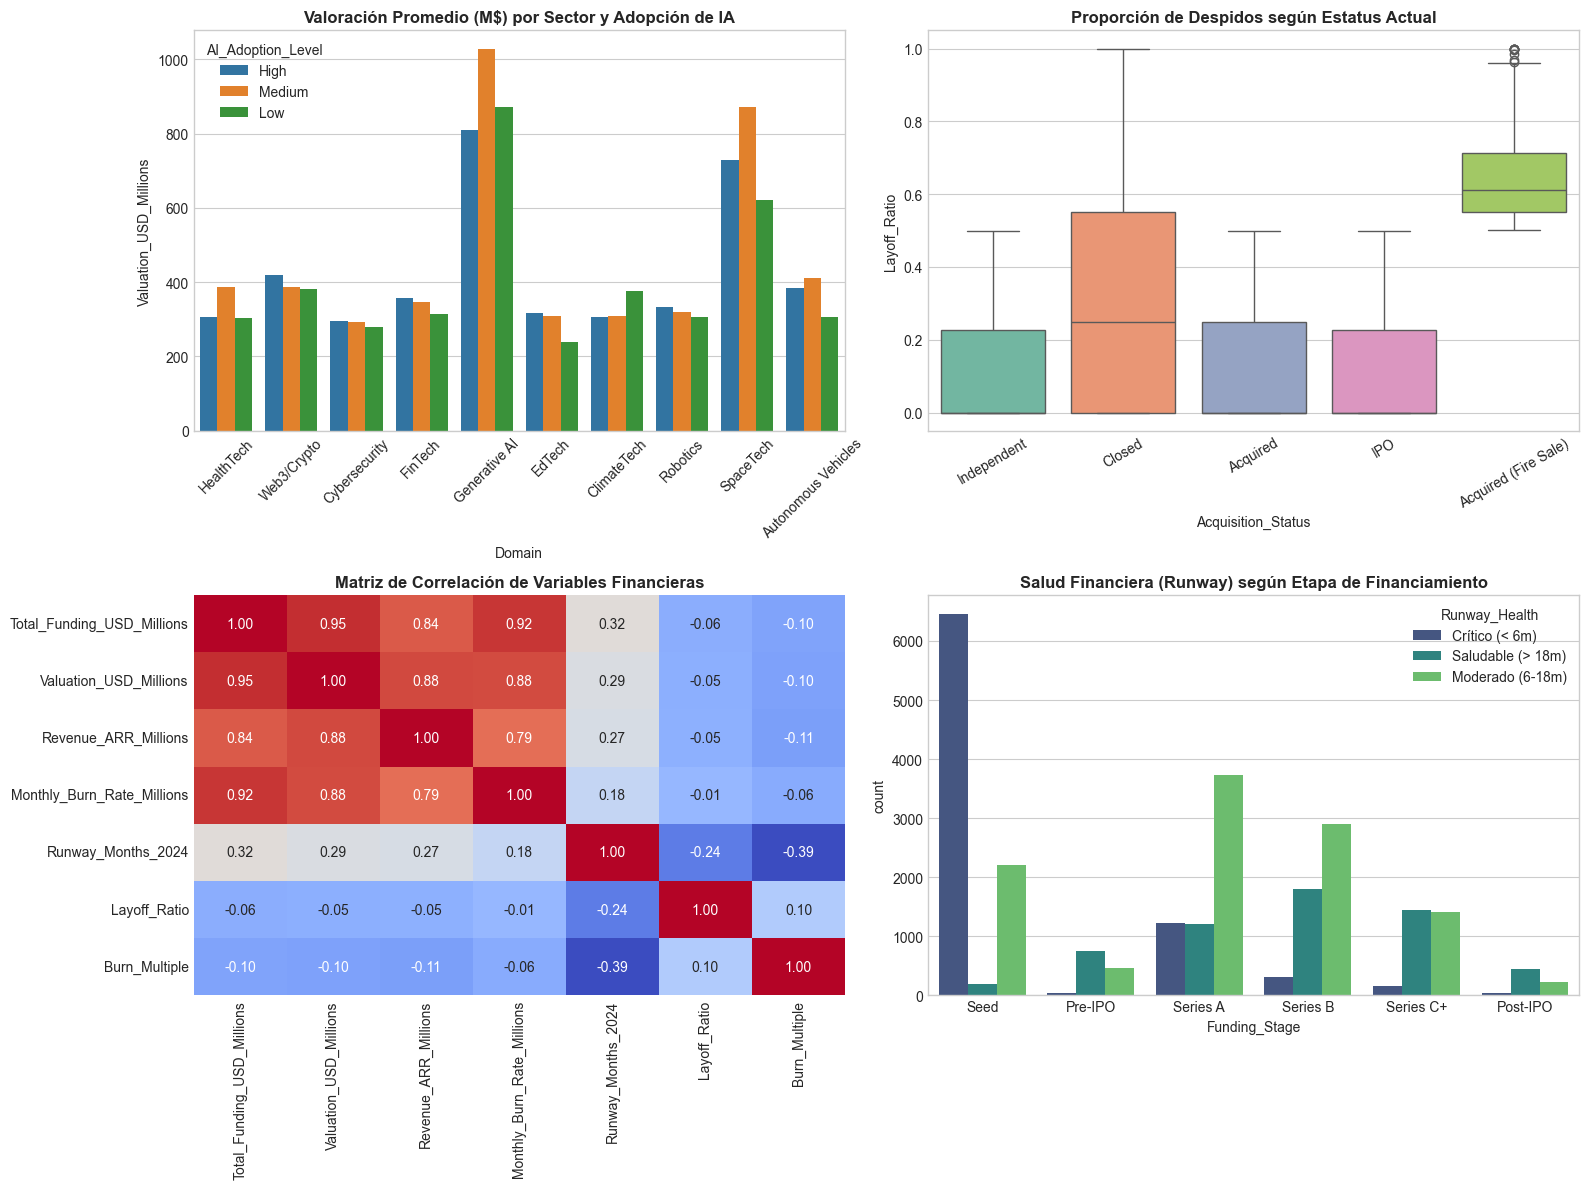

In [4]:
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gráfico 1: Valoración Media por Dominio y Adopción de IA
sns.barplot(data=df, x='Domain', y='Valuation_USD_Millions', hue='AI_Adoption_Level', ax=axes[0, 0], ci=None)
axes[0, 0].set_title('Valoración Promedio (M$) por Sector y Adopción de IA', fontsize=12, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)

# Gráfico 2: Distribución de Despidos (Layoff Ratio) por Estado de la Startup
sns.boxplot(data=df, x='Acquisition_Status', y='Layoff_Ratio', palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('Proporción de Despidos según Estatus Actual', fontsize=12, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=30)

# Gráfico 3: Matriz de Correlación Financiera
numeric_cols = ['Total_Funding_USD_Millions', 'Valuation_USD_Millions', 'Revenue_ARR_Millions', 
                'Monthly_Burn_Rate_Millions', 'Runway_Months_2024', 'Layoff_Ratio', 'Burn_Multiple']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 0], cbar=False)
axes[1, 0].set_title('Matriz de Correlación de Variables Financieras', fontsize=12, fontweight='bold')

# Gráfico 4: Distribución de Runway Health por Stage
sns.countplot(data=df, x='Funding_Stage', hue='Runway_Health', palette='viridis', ax=axes[1, 1])
axes[1, 1].set_title('Salud Financiera (Runway) según Etapa de Financiamiento', fontsize=12, fontweight='bold')

plt.tight_layout()

# Guardar la imagen en la carpeta 'Images/' para el README de GitHub
plt.savefig('../Images/eda_summary_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
import os

# 1. Crear la carpeta 'Data/processed' automáticamente si no existe
os.makedirs('../Data/processed', exist_ok=True)

# 2. Guardar el archivo CSV
df.to_csv('../Data/processed/startups_cleaned_2026.csv', index=False)
print("✅ Dataset procesado y guardado con éxito en 'Data/processed/startups_cleaned_2026.csv'")

✅ Dataset procesado y guardado con éxito en 'Data/processed/startups_cleaned_2026.csv'
